In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('../python_code').resolve()))
import numpy as np
import cv2
import csv
from scipy.stats import rankdata
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline
from DataGenerator import HyperspectralTorchDataset
from ManualCNNClassifier import HyperspectralCNN

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
image_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Infected/Tray_2_row_0_column_12.npy")
# model_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/HyperspectralMultiCNN_1-92-183-274-365-456-547-638-bands-0.981-accuracy.pt")
model_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/HyperspectralMultiCNN_20-60-100-140-180-220-260-300-340-380-420-460-500-540-580-620-bands-0.943-accuracy.pt")
seeds_root = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds")

In [25]:
# --- Infer Bands and Label ---
model_name = model_path.stem
bands_str = model_name.split("_")[1].split("-bands")[0]
bands = list(map(int, bands_str.split("-")))
label = 0 if "Healthy" in str(image_path) else 1

print(bands, label)

[20, 60, 100, 140, 180, 220, 260, 300, 340, 380, 420, 460, 500, 540, 580, 620] 1


In [28]:
# --- Prepare Image ---
image = np.load(image_path)
height, width = image.shape[:2]
shape = (height, width, len(bands))

In [29]:
dataset = HyperspectralTorchDataset([str(image_path)], [label], bands, shape)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

In [30]:
for image, _ in loader:
    image = image.to(device)

In [ ]:
cnn_model = HyperspectralCNN(len(bands))
# model = SpectralSpatialMultiHeatmapAttentionModel(len(bands))

# Load the state dict
state = torch.load(model_path, map_location=device)

# Strip the prefix, if needed (for example, '_orig_mod.')
state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}

# Get current model state_dict
model_state = cnn_model.state_dict()

# Update only the matching keys
for key in model_state.keys():
    if key in state and state[key].shape == model_state[key].shape:
        model_state[key] = state[key]  # Copy the matching weights

# Load the state_dict into the model
cnn_model.load_state_dict(model_state)

# Now the model is partially loaded with compatible weights
# model = torch.compile(model, backend="eager")
cnn_model.to(device).eval()

In [33]:
logits = cnn_model(image)
print(logits)

tensor([[0.0078]], grad_fn=<AddmmBackward0>)


In [11]:
def find_last_conv_layer(model, n):
    last_conv = None
    count = 0
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv = (name, module)
            if count == n:
                break
            count += 1
    return last_conv  # returns (name, module)

last_conv_name, _ = find_last_conv_layer(cnn_model, 0)
print(f"Last convolutional layer: {last_conv_name}")

Last convolutional layer: model.0


In [12]:
grads = None
def save_gradient(grad):
    global grads
    grads = grad

In [13]:
def generate_gradcam(model, img_tensor, target_layer_name):
    model.eval()
    
    # Forward hook to capture conv output
    conv_output = None
    def forward_hook(module, input, output):
        nonlocal conv_output
        conv_output = output
        output.register_hook(save_gradient)
    
    # Register hook
    layer = dict(model.named_modules())[target_layer_name]
    hook = layer.register_forward_hook(forward_hook)

    # Forward pass
    output = model(img_tensor)
    
    # Backward pass for class score
    model.zero_grad()
    score = output[0, 0]
    score.backward()

    # Remove hook
    hook.remove()

    # Compute per-channel heatmaps
    pooled_grads = torch.mean(grads, dim=(2, 3))  # shape: [n_channels]
    conv_output = conv_output.squeeze(0)  # shape: [n_channels, H, W]
    heatmaps = []
    for i in range(conv_output.shape[0]):
        heatmap = conv_output[i] * pooled_grads[0, i]
        heatmap = torch.relu(heatmap)
        heatmap = heatmap.cpu().detach().numpy()
        heatmap = cv2.resize(heatmap, (img_tensor.shape[3], img_tensor.shape[2]))
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        heatmaps.append(heatmap)
    
    return heatmaps

In [14]:
def plot_heatmaps(heatmaps, cols=8):
    rows = (len(heatmaps) + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, heatmap in enumerate(heatmaps):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(heatmap, cmap='jet')
        plt.axis('off')
        plt.title(f'Channel {i}')
    plt.tight_layout()
    plt.show()

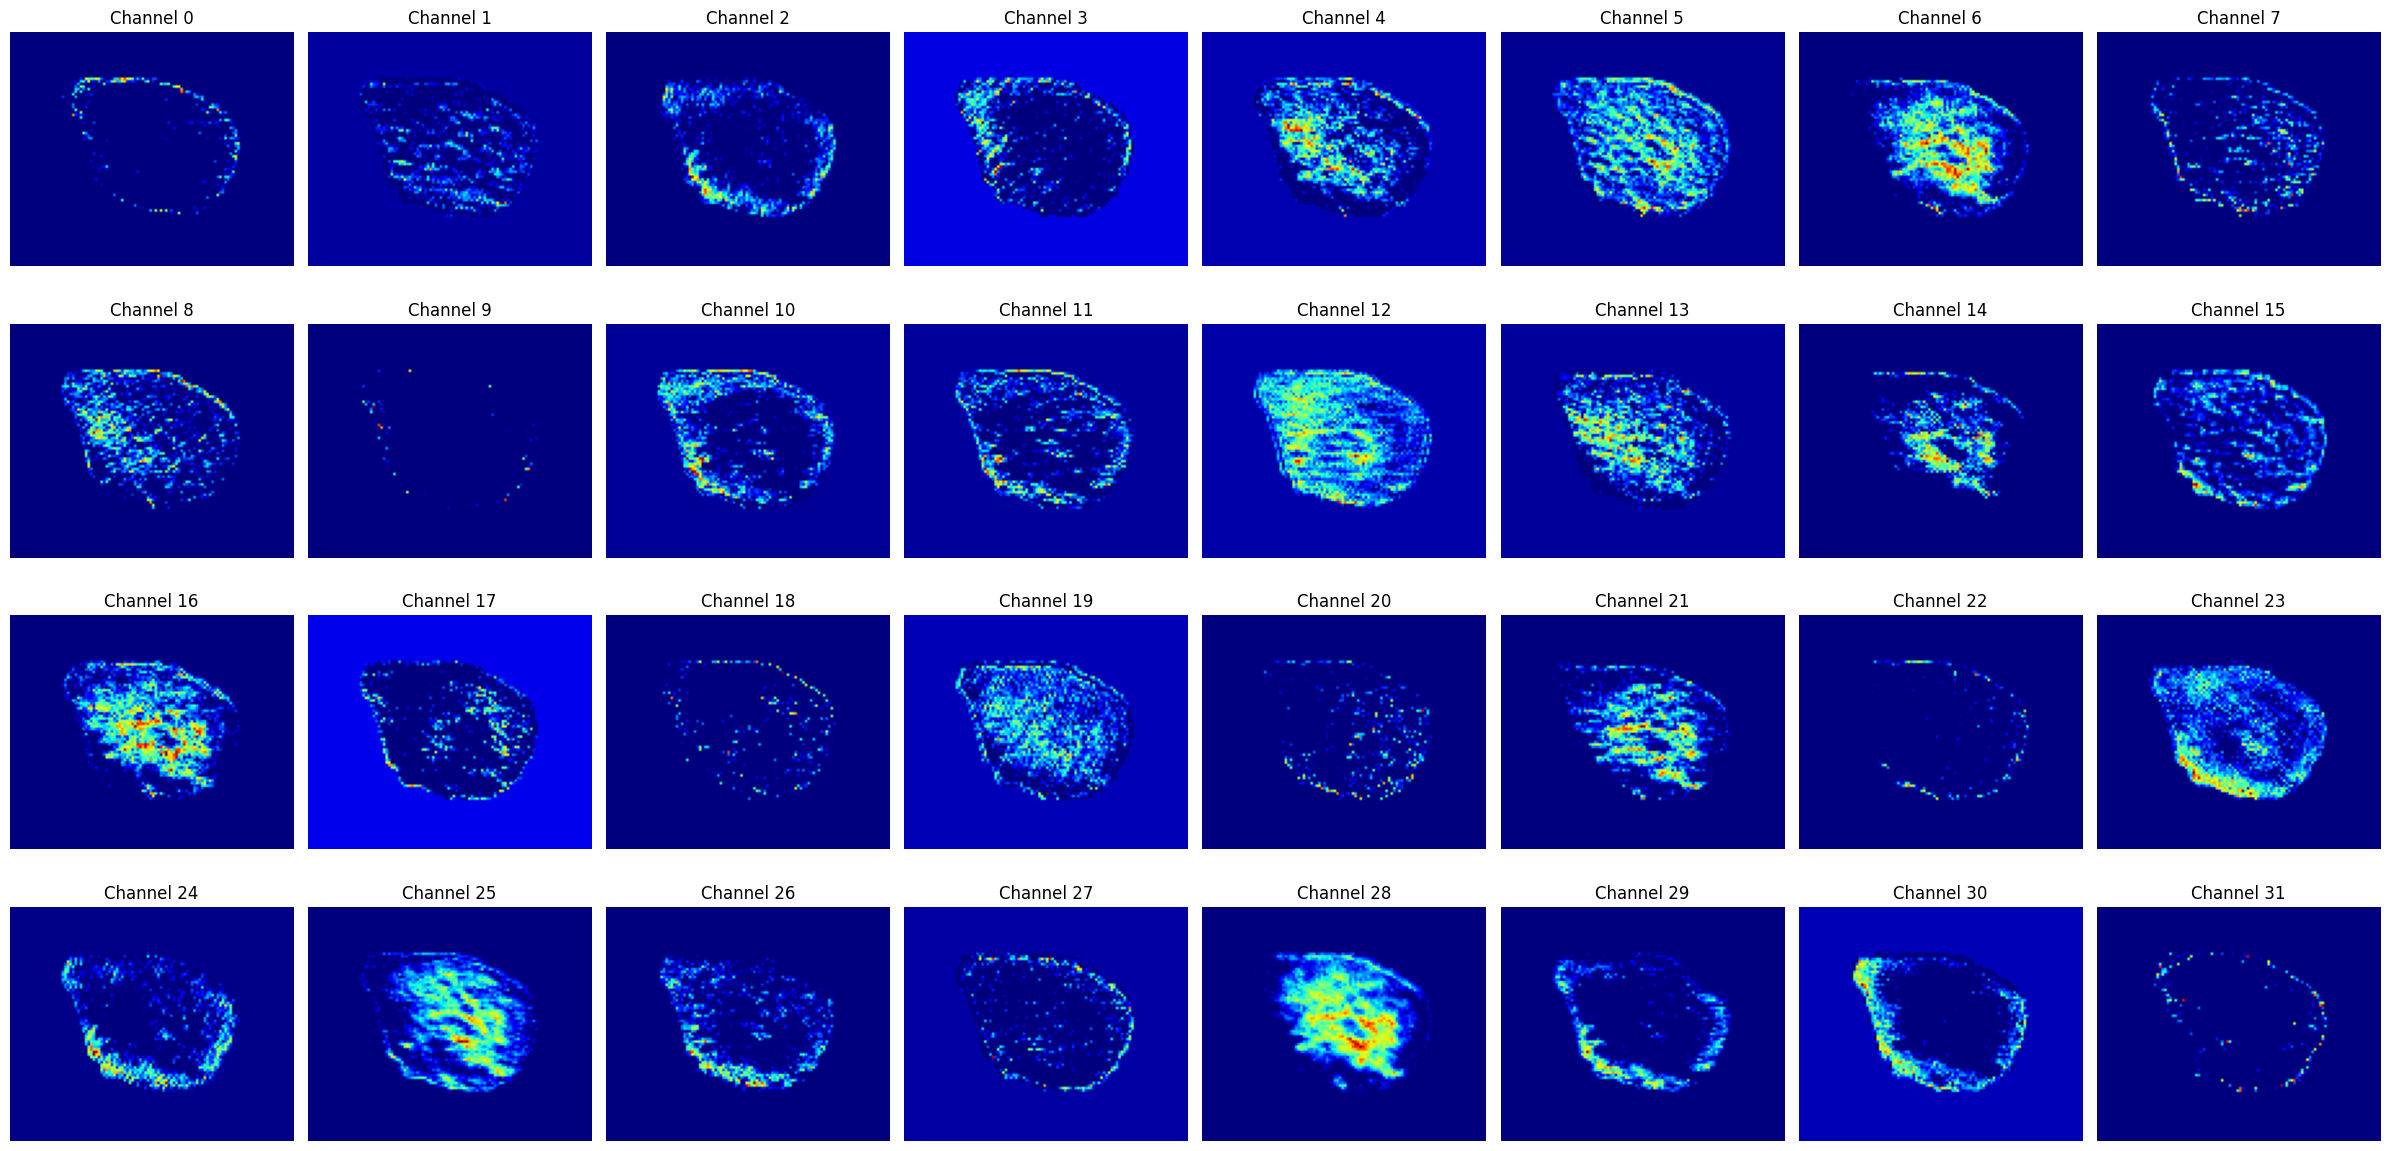

In [15]:
heatmaps = generate_gradcam(cnn_model, image, last_conv_name)
plot_heatmaps(heatmaps)

In [17]:
def generate_input_channel_attributions(model, x):
    model.eval()
    x = x.clone().detach().requires_grad_(True)

    logits = model(x)
    model.zero_grad()
    logits[0, 0].backward()

    grads = x.grad.data  # ∂logit/∂x
    attributions = x * grads  # input × gradient

    # Now generate 1 heatmap per input channel
    heatmaps = []
    for i in range(attributions.shape[1]):  # over channels
        heatmap = attributions[0, i].detach().cpu().numpy()
        heatmap = np.maximum(heatmap, 0)  # ReLU
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        heatmaps.append(heatmap)
    
    return heatmaps

In [18]:
from scipy.spatial.distance import pdist

def calculate_grad_stats(x, heatmaps, grad_threshold_ratio=0.2, epsilon=1e-8):
    x_np = x[0].cpu().numpy()         # [C, H, W]
    heatmaps_np = np.array(heatmaps)  # [C, H, W]
    n = x_np.shape[0]

    mean_grads = []
    high_grad_counts = []
    dispersion_scores = []

    for i in range(n):
        band = x_np[i]
        grad = heatmaps_np[i]
        grad_magnitude = np.abs(grad)

        # High gradient mask based on local band value
        threshold = grad_threshold_ratio * (np.abs(band) + epsilon)
        high_grad_mask = grad_magnitude > threshold

        high_grad_count = int(high_grad_mask.sum())
        high_grad_counts.append(high_grad_count)

        # Mean of high gradients (0 if none)
        if high_grad_count > 0:
            mean_grads.append(grad_magnitude[high_grad_mask].mean())
        else:
            mean_grads.append(0.0)

        # Dispersion score
        coords = np.column_stack(np.nonzero(high_grad_mask))  # (N, 2)
        if high_grad_count > 1:
            dispersion = pdist(coords).mean()  # average pairwise distance
            dispersion_score = high_grad_count / (dispersion + epsilon)
        else:
            dispersion_score = 0.0

        dispersion_scores.append(dispersion_score)

    return mean_grads, high_grad_counts, dispersion_scores

In [19]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.stats import entropy

def calculate_band_stats_extended(
    x,
    heatmaps,
    grad_threshold_ratio=0.2,
    value_percentile=15,
    extreme_percentile=10,
    epsilon=1e-8
):
    x_np = x[0].cpu().numpy()          # [C, H, W]
    heatmaps_np = np.array(heatmaps)   # [C, H, W]
    n = x_np.shape[0]

    mean_grads = []
    high_grad_counts = []
    dispersion_scores = []
    low_value_ratios = []
    extreme_std_scores = []
    contrast_entropies = []

    for i in range(n):
        band = x_np[i]
        grad = np.abs(heatmaps_np[i])
        h, w = band.shape

        # High gradient mask
        threshold = grad_threshold_ratio * (np.abs(band) + epsilon)
        high_grad_mask = grad > threshold
        high_grad_count = high_grad_mask.sum()
        high_grad_counts.append(int(high_grad_count))

        mean_grads.append(grad[high_grad_mask].mean() if high_grad_count > 0 else 0.0)

        coords = np.column_stack(np.nonzero(high_grad_mask))
        if len(coords) > 1:
            dispersion = pdist(coords).mean()
            dispersion_score = high_grad_count / (dispersion + epsilon)
        else:
            dispersion_score = 0.0
        dispersion_scores.append(dispersion_score)

        # Low value ratio
        low_thresh = np.percentile(band, value_percentile)
        low_value_ratio = (band < low_thresh).sum() / (h * w)
        low_value_ratios.append(low_value_ratio)

        # Extreme std (std of lowest and highest extremes)
        low_vals = band[band < np.percentile(band, extreme_percentile)]
        high_vals = band[band > np.percentile(band, 100 - extreme_percentile)]
        if len(low_vals) + len(high_vals) > 1:
            extreme_std = np.std(np.concatenate([low_vals, high_vals]))
        else:
            extreme_std = 0.0
        extreme_std_scores.append(extreme_std)

        # Gradient contrast entropy
        hist, _ = np.histogram(grad.ravel(), bins=32, range=(0, grad.max() + epsilon), density=True)
        contrast_entropies.append(entropy(hist + epsilon))

    return {
        "mean_grad": mean_grads,
        "high_grad_count": high_grad_counts,
        "dispersion": dispersion_scores,
        "low_value_ratio": low_value_ratios,
        "extreme_std_score": extreme_std_scores,
        "contrast_entropy": contrast_entropies
    }

In [20]:
def min_max_normalize(arr):
    arr = np.array(arr)
    arr_min = arr.min()
    arr_max = arr.max()
    return (arr - arr_min) / (arr_max - arr_min + 1e-8)

In [21]:
def calculate_weighted_sensitivity(
    x, heatmaps, grad_threshold_ratio=0.2, 
    weight_change=1.0, weight_high_grad=1.0, 
    epsilon=1e-8
):
    mean_grads, high_grads_numbers, dispersion_scores = calculate_grad_stats(x, heatmaps, grad_threshold_ratio, epsilon)

    # Min-max scaling for percentiles
    min_grad, max_grad_val = np.min(mean_grads), np.max(mean_grads)
    min_high, max_high = np.min(high_grads_numbers), np.max(high_grads_numbers)

    mean_grad_percentiles = [
        (val - min_grad) / (max_grad_val - min_grad + epsilon)
        for val in mean_grads
    ]
    high_grad_percentiles = [
        (val - min_high) / (max_high - min_high + epsilon)
        for val in high_grads_numbers
    ]

    # Combined sensitivity score
    sensitivity_scores = [
        weight_change * c + weight_high_grad * h
        for c, h in zip(mean_grad_percentiles, high_grad_percentiles)
    ]

    return (
        sensitivity_scores,
        mean_grad_percentiles,
        high_grad_percentiles,
        mean_grads,
        high_grads_numbers,
        dispersion_scores,
    )

In [22]:
def plot_band_heatmap_overlay(x, heatmaps, bands, grad_threshold_ratio, weight_change, weight_high_grad, weight_dispersion, cols=3):
    import numpy as np
    import matplotlib.pyplot as plt

    x_np = x[0].cpu().numpy()            # shape: [C, H, W]
    heatmaps_np = np.array(heatmaps)     # shape: [C, H, W]
    n = x_np.shape[0]
    rows = n

    # Compute sensitivity score per band
    sensitivities, mean_grad_percentiles, high_grad_percentiles, mean_grads, high_grads_numbers, dispersion_scores = calculate_weighted_sensitivity(x, heatmaps, grad_threshold_ratio=grad_threshold_ratio, weight_change=weight_change, weight_high_grad=weight_high_grad)
    print(np.array(sensitivities).tolist())

    normalized_mean_grads = min_max_normalize(mean_grads)
    normalized_high_grads_numbers = min_max_normalize(high_grads_numbers)
    normalized_dispersion_scores = min_max_normalize(dispersion_scores)
    print('-------------------', np.array(mean_grads).tolist(), high_grads_numbers, np.array(dispersion_scores).tolist(), normalized_mean_grads + normalized_high_grads_numbers + normalized_dispersion_scores, sep="\n")
    print('-------------------', normalized_mean_grads, normalized_high_grads_numbers, normalized_dispersion_scores, sep="\n")
    print((weight_change * np.array(normalized_mean_grads) + weight_high_grad * np.array(normalized_high_grads_numbers) + weight_dispersion * np.array(normalized_dispersion_scores)).tolist())

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 2.5))
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    # Global normalization
    band_vals = np.concatenate([x_np[i].flatten() for i in range(n)])
    heatmap_vals = np.concatenate([heatmaps_np[i].flatten() for i in range(n)])
    overlays = [x_np[i] * heatmaps_np[i] for i in range(n)]
    overlay_vals = np.concatenate([o.flatten() for o in overlays])

    band_min, band_max = band_vals.min(), band_vals.max()
    heat_min, heat_max = heatmap_vals.min(), heatmap_vals.max()
    overlay_min, overlay_max = overlay_vals.min(), overlay_vals.max()

    for i in range(n):
        band = x_np[i]
        heatmap = heatmaps_np[i]
        overlay = overlays[i]

        # Normalize using global stats
        band_disp = (band - band_min) / (band_max - band_min + 1e-8)
        heatmap_disp = (heatmap - heat_min) / (heat_max - heat_min + 1e-8)
        overlay_disp = (overlay - overlay_min) / (overlay_max - overlay_min + 1e-8)

        # Band (left)
        axes[i, 0].imshow(band_disp, cmap='gray')
        axes[i, 0].axis('off')
        axes[i, 0].text(-0.15, 0.6, f'Band {bands[i]}', fontsize=10, va='center', ha='right', transform=axes[i, 0].transAxes)
        axes[i, 0].text(-0.15, 0.4, f'Sensitivity: {sensitivities[i]:.3f}\nmean gradient: {mean_grads[i]:.3f} - {mean_grad_percentiles[i]:.3f}%\nhigh grad number: {high_grads_numbers[i]:.3f} - {high_grad_percentiles[i]:.3f}%', fontsize=9, va='center', ha='right', transform=axes[i, 0].transAxes, color='gray')

        # Heatmap (middle)
        axes[i, 1].imshow(heatmap_disp, cmap='jet')
        axes[i, 1].axis('off')

        # Overlay (right)
        axes[i, 2].imshow(overlay_disp, cmap='jet')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

true label: 1, predicted label: 0.007821109145879745
heatmaps shape: 16, (91, 110)
[0.18970463567986265, 0.0, 0.11487005302814333, 0.3091101725722043, 0.4324637311484798, 0.2680971993320705, 0.1698519788125994, 0.45554451941960755, 0.46595962697940074, 0.513276056977054, 0.43163253682004393, 0.4837968012238095, 0.4563845551216375, 0.5091787260765908, 0.30926635380413264, 0.20679680178126214]
-------------------
[0.12376251071691513, 0.09324010461568832, 0.1076837033033371, 0.14391836524009705, 0.17135274410247803, 0.15399999916553497, 0.12112756818532944, 0.1580275595188141, 0.18570689857006073, 0.1967628002166748, 0.21024395525455475, 0.20440462231636047, 0.21109645068645477, 0.21819619834423065, 0.19227562844753265, 0.17816786468029022]
[530, 289, 455, 677, 796, 542, 502, 910, 794, 837, 601, 738, 648, 722, 437, 295]
[19.54027932903714, 10.522236197262044, 16.390652115362727, 24.351128671655967, 28.83788705062046, 20.277030082458726, 18.60768172834213, 35.68306135871855, 29.5928093778

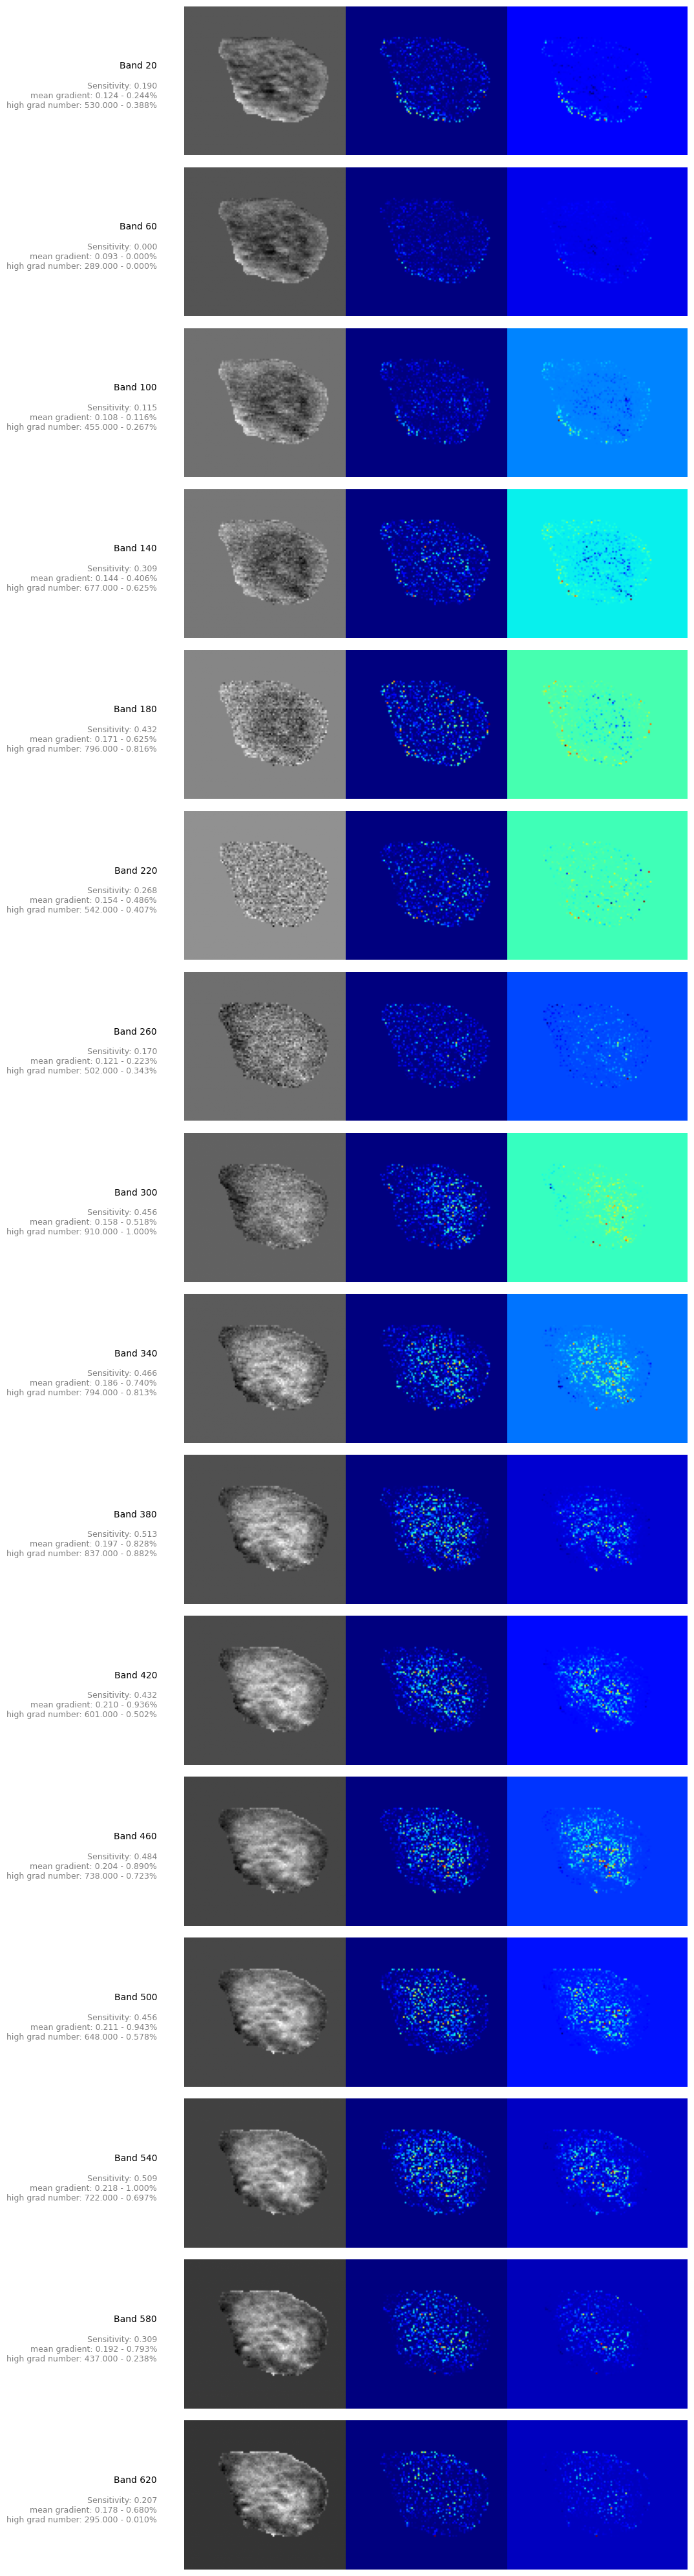

In [34]:
print(f'true label: {label}, predicted label: {logits[0, 0]}')
# heatmaps = generate_gradcam(model, image, last_conv_name)
heatmaps = generate_input_channel_attributions(cnn_model, image)
print(f'heatmaps shape: {len(heatmaps)}, {heatmaps[0].shape}')
plot_band_heatmap_overlay(image, heatmaps, bands, 0.1, 0.3, 0.3, 0.3)

In [25]:
seed_paths = list(Path(seeds_root).rglob("*.npy"))
labels = [0 if "Healthy" in str(path) else 1 for path in seed_paths]

In [26]:
def save_grad_stats_csv(
    model,
    loader,
    band_scores,  # list of band-only classification accuracies
    thresholds,
    csv_path
):
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["label", "threshold", "mean_grad", "high_grad_count", "dispersion", "band_only_accuracy"])

        for image, label in loader:
            image = image.to(device)
            heatmaps = generate_input_channel_attributions(model, image)

            for threshold in thresholds:
                mean_grads, high_grads, dispersion_scores = calculate_grad_stats(image, heatmaps, grad_threshold_ratio=threshold)
                normalized_mean_grads = min_max_normalize(mean_grads)
                normalized_high_grads = min_max_normalize(high_grads)
                normalized_dispersion_scores = min_max_normalize(dispersion_scores)

                for i, (mg, hg, ds) in enumerate(zip(normalized_mean_grads, normalized_high_grads, normalized_dispersion_scores)):
                    writer.writerow([
                        int(label),
                        threshold,
                        round(mg, 3),
                        round(hg, 3),
                        round(ds, 3),
                        round(band_scores[i], 4)
                    ])

In [27]:
def save_grad_stats_csv_extended(
    model,
    loader,
    band_scores,
    thresholds,
    csv_path
):
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "label", "threshold",
            "mean_grad", "high_grad_count", "dispersion",
            "low_value_ratio", "extreme_std_score", "contrast_entropy",
            "band_only_accuracy"
        ])

        for image, label in loader:
            image = image.to(device)
            heatmaps = generate_input_channel_attributions(model, image)

            for threshold in thresholds:
                stats = calculate_band_stats_extended(image, heatmaps, grad_threshold_ratio=threshold)

                # Normalize all values band-wise
                normalized = {k: min_max_normalize(v) for k, v in stats.items()}

                for i in range(len(band_scores)):
                    writer.writerow([
                        int(label),
                        threshold,
                        round(normalized["mean_grad"][i], 3),
                        round(normalized["high_grad_count"][i], 3),
                        round(normalized["dispersion"][i], 3),
                        round(normalized["low_value_ratio"][i], 3),
                        round(normalized["extreme_std_score"][i], 3),
                        round(normalized["contrast_entropy"][i], 3),
                        round(band_scores[i], 4)
                    ])

In [28]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
csv_path = "band_stats.csv"
single_band_accuracies = [0.78, 0.893, 0.91, 0.913, 0.832, 0.894, 0.838, 0.927, 0.91, 0.944, 0.945]

loader = DataLoader(HyperspectralTorchDataset(seed_paths, labels, bands, shape), batch_size=1, shuffle=False)

try:
    save_grad_stats_csv_extended(cnn_model, loader, single_band_accuracies, thresholds, csv_path)
except Exception as e:
    print(f"An error occurred: {e}")

An error occurred: too many indices for array: array is 2-dimensional, but 3 were indexed


In [29]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score
from itertools import product

def grid_search_best_score(csv_path, weight_steps=0.1):
    df = pd.read_csv(csv_path)
    thresholds = sorted(df['threshold'].unique())

    best_r2 = -np.inf
    best_config = None

    weight_range = np.arange(0, 1.01, weight_steps)

    for threshold in thresholds:
        subset = df[df['threshold'] == threshold]

        X = subset[['mean_grad', 'high_grad_count', 'dispersion']].values
        y = subset['band_only_accuracy'].values

        for w1, w2, w3 in product(weight_range, repeat=3):
            # Skip weights that sum to 0
            if (w1 + w2 + w3) == 0:
                continue

            # Normalize weights to sum to 1
            total = w1 + w2 + w3
            w1, w2, w3 = w1 / total, w2 / total, w3 / total

            score = w1 * X[:, 0] + w2 * X[:, 1] + w3 * X[:, 2]
            r2 = r2_score(y, score)

            if r2 > best_r2:
                best_r2 = r2
                best_config = {
                    "threshold": threshold,
                    "w1_mean_grad": w1,
                    "w2_high_count": w2,
                    "w3_dispersion": w3,
                    "r2_score": r2
                }

    return best_config

best = grid_search_best_score("band_stats.csv", weight_steps=0.05)
print("📏 Best threshold:", best["threshold"])
print("🧠 Best weights:")
print("   Mean grad     :", round(best["w1_mean_grad"], 3))
print("   High count    :", round(best["w2_high_count"], 3))
print("   Dispersion    :", round(best["w3_dispersion"], 3))
print("📈 Best R² score :", round(best["r2_score"], 4))

📏 Best threshold: 0.0
🧠 Best weights:
   Mean grad     : 0.452
   High count    : 0.31
   Dispersion    : 0.238
📈 Best R² score : -96.7712


In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

# Load and clean data
csv_path = "band_stats.csv"  # ← update if needed
df = pd.read_csv(csv_path)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Define input features (use all six)
feature_cols = ["mean_grad"]
# feature_cols = [
#     "mean_grad", "high_grad_count", "dispersion",
#     "low_value_ratio", "extreme_std_score", "contrast_entropy"
# ]

best_score = -np.inf
best_threshold = None
best_model = None

# Try models for each threshold
for threshold in sorted(df["threshold"].unique()):
    subset = df[df["threshold"] == threshold]

    X = subset[feature_cols].values
    y = subset["band_only_accuracy"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    mlp_regressor_model = MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    mlp_regressor_model.fit(X_train, y_train)

    y_pred = mlp_regressor_model.predict(X_test)
    score = r2_score(y_test, y_pred)

    if score > best_score:
        best_score = score
        best_threshold = threshold
        best_model = mlp_regressor_model

print("📏 Best threshold:", best_threshold)
print("🧠 Best R² score:", round(best_score, 4))


📏 Best threshold: 1.0
🧠 Best R² score: -11.2291


In [ ]:
loader = DataLoader(HyperspectralTorchDataset(seed_paths, labels, bands, shape), batch_size=1, shuffle=False)

normalized_mean_grads = np.zeros(len(bands))
normalized_high_grads = np.zeros(len(bands))
normalized_dispersion_scores = np.zeros(len(bands))

try:
    for image, label in loader:
        image = image.to(device)
        heatmaps = generate_input_channel_attributions(cnn_model, image)
        mean_grads, high_grads, dispersion_scores = calculate_grad_stats(image, heatmaps, grad_threshold_ratio=best_threshold)
        normalized_mean_grads += min_max_normalize(mean_grads)
        normalized_high_grads += min_max_normalize(high_grads)
        normalized_dispersion_scores += min_max_normalize(dispersion_scores)
except Exception as e:
    print(f"An error occurred: {e}")

normalized_mean_grads /= len(bands)
normalized_high_grads /= len(bands)
normalized_dispersion_scores /= len(bands)

# print((round(best["weights"][0], 3) * np.array(normalized_mean_grads) + round(best["weights"][1], 3) * np.array(normalized_high_grads) + round(best["weights"][2], 3) * np.array(normalized_dispersion_scores)).tolist())
print(best_model.predict(np.stack([normalized_mean_grads, normalized_high_grads, normalized_dispersion_scores], axis=1)).tolist())


In [32]:
loader = DataLoader(HyperspectralTorchDataset(seed_paths, labels, bands, shape), batch_size=1, shuffle=False)

normalized_mean_grads = np.zeros(len(bands))
normalized_high_grads = np.zeros(len(bands))
normalized_dispersion_scores = np.zeros(len(bands))
normalized_low_value_ratio = np.zeros(len(bands))
normalized_extreme_std_score = np.zeros(len(bands))
normalized_contrast_entropy = np.zeros(len(bands))

try:
    for image, label in loader:
        image = image.to(device)
        heatmaps = generate_input_channel_attributions(cnn_model, image)

        (
            mean_grads, high_grads, dispersion_scores,
            low_value_ratio, extreme_std_score, contrast_entropy
        ) = calculate_band_stats_extended(image, heatmaps, grad_threshold_ratio=best_threshold).values()

        normalized_mean_grads += min_max_normalize(mean_grads)
        normalized_high_grads += min_max_normalize(high_grads)
        normalized_dispersion_scores += min_max_normalize(dispersion_scores)
        normalized_low_value_ratio += min_max_normalize(low_value_ratio)
        normalized_extreme_std_score += min_max_normalize(extreme_std_score)
        normalized_contrast_entropy += min_max_normalize(contrast_entropy)

except Exception as e:
    print(f"An error occurred: {e}")

# Average over images
normalized_mean_grads /= len(bands)
normalized_high_grads /= len(bands)
normalized_dispersion_scores /= len(bands)
normalized_low_value_ratio /= len(bands)
normalized_extreme_std_score /= len(bands)
normalized_contrast_entropy /= len(bands)

# Stack all 6 features for prediction
X = np.stack([
    normalized_mean_grads,
    # normalized_high_grads,
    # normalized_dispersion_scores,
    # normalized_low_value_ratio,
    # normalized_extreme_std_score,
    # normalized_contrast_entropy
], axis=1)

# Predict band scores
band_scores = best_model.predict(X)
print(band_scores.tolist())


An error occurred: too many indices for array: array is 2-dimensional, but 3 were indexed
[0.7418658368772488, 0.7418658368772488, 0.7418658368772488, 0.7418658368772488, 0.7418658368772488, 0.7418658368772488, 0.7418658368772488, 0.7418658368772488, 0.7418658368772488, 0.7418658368772488, 0.7418658368772488]


In [33]:
print(df[df["threshold"] == best_threshold][["mean_grad", "high_grad_count", "dispersion", "band_only_accuracy"]].describe())

        mean_grad  high_grad_count  dispersion  band_only_accuracy
count  264.000000       264.000000  264.000000          264.000000
mean     0.157970         0.116352    0.095826            0.889636
std      0.316389         0.288077    0.264431            0.049481
min      0.000000         0.000000    0.000000            0.780000
25%      0.000000         0.000000    0.000000            0.838000
50%      0.000000         0.000000    0.000000            0.910000
75%      0.000000         0.000000    0.000000            0.927000
max      1.000000         1.000000    1.000000            0.945000


In [34]:
from sklearn.metrics.pairwise import cosine_similarity

def generate_similarity_table_from_heatmaps(heatmaps):
    """
    heatmaps: list or array of shape [num_bands, H, W] or [num_bands, H*W]
    returns: similarity matrix [num_bands x num_bands] using cosine similarity
    """
    num_bands = len(heatmaps)
    flattened = np.array([h.flatten() for h in heatmaps])
    similarity_matrix = cosine_similarity(flattened)
    return similarity_matrix

In [35]:
def select_top_k_bands(accuracies, similarity_matrix, k=3, lambd=0.5):
    """
    accuracies: list of per-band accuracies
    similarity_matrix: cosine similarity matrix between bands
    k: number of bands to select
    lambd: redundancy penalty weight
    returns: list of selected band indices
    """
    selected = []
    num_bands = len(accuracies)

    while len(selected) < k:
        best_score = -np.inf
        best_band = None

        for i in range(num_bands):
            if i in selected:
                continue
            if selected:
                redundancy_penalty = np.mean([similarity_matrix[i][j] for j in selected])
            else:
                redundancy_penalty = 0
            score = accuracies[i] - lambd * redundancy_penalty
            if score > best_score:
                best_score = score
                best_band = i

        selected.append(best_band)

    return selected

In [54]:
similarity_matrix = generate_similarity_table_from_heatmaps(heatmaps)
selected_bands = select_top_k_bands(band_scores, similarity_matrix, k=3, lambd=-5)
print("Top-k selected bands:", selected_bands)

Top-k selected bands: [0, 1, 6]
